In [27]:
!pip install pymittagleffler

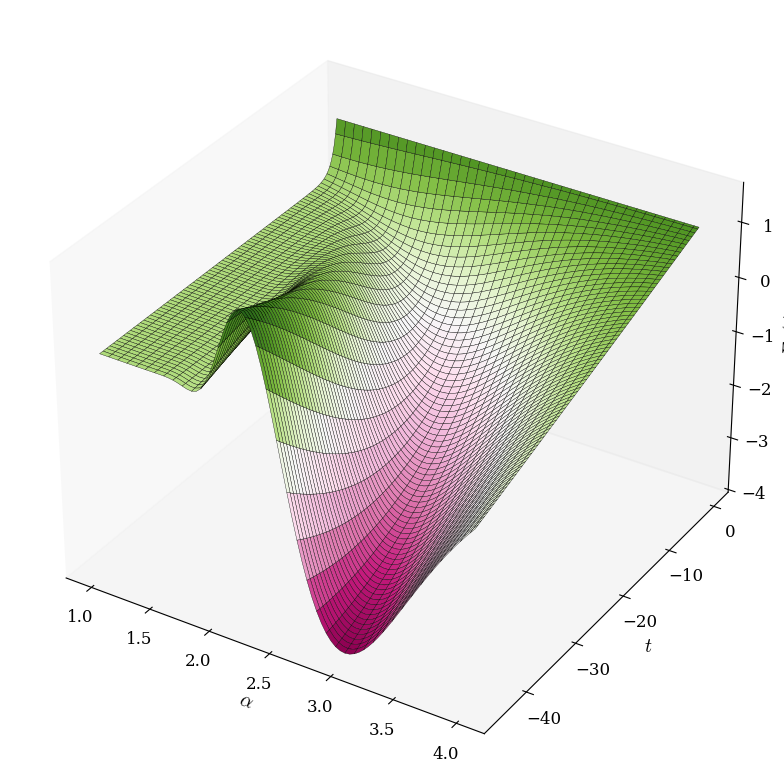

In [28]:
# ==========================================================
# Instale uma única vez
# ==========================================================

!pip install pymittagleffler -q

# ==========================================================
# Bibliotecas
# ==========================================================

import numpy as np
import matplotlib.pyplot as plt
from pymittagleffler import mittag_leffler

# ==========================================================
# Domínio semelhante ao gráfico de Camargo
# ==========================================================

alpha = np.linspace(1.0, 4.0, 80)
t = np.linspace(-45.0, 0.0, 150)

A, T = np.meshgrid(alpha, t)

# ==========================================================
# Cálculo da superfície
# ==========================================================

Z = np.zeros_like(A, dtype=float)

for i in range(A.shape[0]):
    for j in range(A.shape[1]):

        try:

            z = mittag_leffler(
                T[i, j],   # variável
                A[i, j],   # alpha
                1.0        # beta=1 => E_alpha(z)
            )

            Z[i, j] = np.real(z)

        except:
            Z[i, j] = np.nan

# ==========================================================
# Figura
# ==========================================================

plt.rcParams.update({
    "font.family": "serif",
    "mathtext.fontset": "cm",
    "font.size": 12
})

fig = plt.figure(figsize=(10,8))

ax = fig.add_subplot(
    111,
    projection='3d'
)

# ==========================================================
# Superfície
# ==========================================================

surf = ax.plot_surface(
    A,
    T,
    Z,
    cmap='PiYG',
    edgecolor='black',
    linewidth=0.25,
    antialiased=True,
    rstride=2,
    cstride=2
)

# ==========================================================
# Eixos
# ==========================================================

ax.set_xlabel(r'$\alpha$', fontsize=14)
ax.set_ylabel(r'$t$', fontsize=14)
ax.set_zlabel(r'$E_{\alpha}(t)$', fontsize=14)

# ==========================================================
# Perspectiva semelhante à figura do Camargo
# ==========================================================

ax.view_init(
    elev=32,
    azim=-58
)

# ==========================================================
# Melhor aparência
# ==========================================================

ax.xaxis.pane.fill = True
ax.yaxis.pane.fill = True
ax.zaxis.pane.fill = True

ax.grid(False)

plt.tight_layout()

# ==========================================================
# Salvar para a dissertação
# ==========================================================

plt.savefig(
    "Mittag_Leffler_Camargo.pdf",
    dpi=600,
    bbox_inches="tight"
)

plt.savefig(
    "Mittag_Leffler_Camargo.png",
    dpi=600,
    bbox_inches="tight"
)

plt.show()

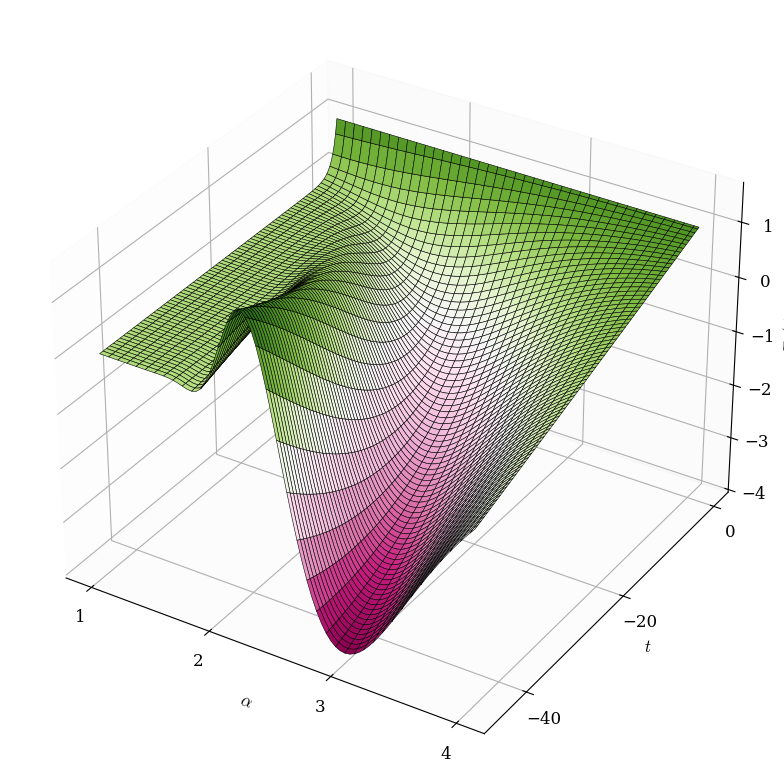

In [29]:
fig2 = plt.figure(figsize=(10,8))
ax2 = fig2.add_subplot(111, projection='3d')

ax2.plot_surface(
    A,
    T,
    Z,
    cmap='PiYG',
    edgecolor='black',
    linewidth=0.40,
    antialiased=True,
    rstride=2,
    cstride=2
)

ax2.set_xlabel(r'$\alpha$')
ax2.set_ylabel(r'$t$')
ax2.set_zlabel(r'$E_{\alpha}(t)$')

ax2.set_xticks([1,2,3,4])
ax2.set_yticks([-40,-20,0])

ax2.view_init(elev=32, azim=-58)

ax2.xaxis.pane.set_alpha(0.15)
ax2.yaxis.pane.set_alpha(0.15)
ax2.zaxis.pane.set_alpha(0.15)

plt.tight_layout()
plt.show()